# Ultrasonic Sensing of Plant Water Needs for Agriculture — inverse-problem parameter extraction

**Paper:** T. Gómez Álvarez-Arenas et al., *Ultrasonic Sensing of Plant Water Needs for Agriculture*, **Sensors 2016, 16(7), 1089**, DOI [10.3390/s16071089](https://doi.org/10.3390/s16071089) (open access, PMC4970135).

**Author code:** `usbiomat/ultrasonic-thickness-resonance` @ commit `09f11ea846ec84d575177dbce773388a4b590f3f` (CT14_GD program + author IPython notebook, reference [44] of the paper).

**Executed scope (one example):** the paper's Section 3.5 data-processing inverse problem. From **one measured first thickness-resonance transmission spectrum** (magnitude in dB and phase in rad) of a homogeneous layer in air at normal incidence, a gradient-descent fit of a theoretical transmission model extracts: layer thickness, density, ultrasound velocity, attenuation coefficient at resonance, attenuation power-law exponent, and resonant frequency. This is the paper's generic plate/membrane demonstration (the leaf-specific spectra of Sections 5.1–5.2 are not publicly archived). **One example is not a reproduction of the paper's leaf results or dataset-level claims.**

**AI-assisted translation notice (EN):** the CT14_GD program was published for Python 2.7. This notebook is an AI-assisted translation to Python 3 of the authors' own pinned code; the numerics are preserved verbatim (only `print()`, paths, and file loading were adapted). The authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed.

**AI翻訳に関する注記（JA）：** 著者公開の Python 2.7 用 CT14_GD プログラムを Python 3 向けに翻訳したものです。数値計算は元コードのまま（`print()`・パス・データ読み込みのみ適応）。実行例と検証項目は確認済みですが、未検証の挙動は保証されません。

**Reference outputs (from the authors' own notebook, embedded results):** resonant frequency 1.33 MHz; thickness 138.0685968 µm; density 346.107549754 kg/m³; velocity 367.262467487 m/s; attenuation 445.603355915 Np/m; attenuation exponent 1.8. Independently measured: 140 µm thick, density 340 kg/m³. We compare our run against these values.

**Runtime:** CPU only (pure NumPy; no deep-learning framework is involved). **ランタイム：CPU のみ**（純 NumPy 計算）。*Runtime → Change runtime type → CPU* is sufficient; expected end-to-end time: well under 15 minutes; total download: one 6.8 kB text file. No license file is present in the author repository; this notebook uses the code for educational demonstration with attribution — reuse terms must be checked with the author before any other use.

## 1. Environment setup / 環境セットアップ

Only NumPy and matplotlib are required — both preinstalled in Colab. We print versions for reproducibility. No GPU is used: the method is a small least-squares-style gradient descent over a few dozen spectral points.
必要なのは NumPy と matplotlib のみ（Colab にプリインストール済み）。手法は小型の勾配降下法であり GPU は不要です。

In [ ]:
import sys, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.13.15
numpy: 2.1.3
matplotlib: 3.10.0


## 2. Minimal input with provenance / 最小入力データの取得

We download `data.dat` — the authors' own sample measured transmission spectrum (membrane, measured in air at normal incidence through transmission with 2.0 MHz air-coupled transducers) — pinned to the exact commit `09f11ea846ec84d575177dbce773388a4b590f3f` of the author repository. Format: three columns `[frequency (Hz), magnitude (dB), phase (rad)]`. We verify byte count and parseability before use.
著者リポジトリの指定コミットから、著者自身のサンプル測定スペクトル `data.dat`（膜試料、3 列：周波数 Hz / 振幅 dB / 位相 rad）をダウンロードし、バイト数と解析可能性を確認します。

In [ ]:
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/usbiomat/ultrasonic-thickness-resonance/09f11ea846ec84d575177dbce773388a4b590f3f/data.dat"
EXPECTED_MIN_BYTES = 1000  # tiny ASCII table; reject HTML error pages

with urllib.request.urlopen(DATA_URL, timeout=60) as r:
    payload = r.read()
print("HTTP bytes:", len(payload))
if len(payload) < EXPECTED_MIN_BYTES or not payload.lstrip().startswith((b"0", b"1", b"2", b"3", b"4", b"5", b"6", b"7", b"8", b"9", b" ", b"-")):
    raise RuntimeError("data.dat download does not look like the expected ASCII spectrum table")

data_path = "/content/data.dat"
with open(data_path, "wb") as f:
    f.write(payload)

import hashlib
print("SHA-256:", hashlib.sha256(payload).hexdigest())
test0 = np.loadtxt(data_path)
print("rows:", test0.shape, "(expect 3 columns: Hz, dB, rad)")
print("frequency range (MHz): %.3f - %.3f" % (test0[:,0].min()/1e6, test0[:,0].max()/1e6))

HTTP bytes: 6811
SHA-256: 3d1469f8448430c0819ed0cc453f07d1bdecef0dfe046713e83f013031ff2a99
rows: (139, 3) (expect 3 columns: Hz, dB, rad)
frequency range (MHz): 0.920 - 2.300


## 3. Author's CT14_GD program (verbatim port to Python 3) / 著者プログラムの移植

The cell below is the authors' CT14_GD code (lines 1–348 of the published program, identical to cell 5 of the authors' `Thickness_resonance_CT14_GD.ipynb`), preserved verbatim except for the Python 3 `print()` function. It defines: `CoefTrans` (transmission-coefficient spectra: resonant frequency, Q factor, -N dB window, error metrics), `medium`/`layer` (surrounding fluid / plate parameters), the theoretical transmission model (`attyRho`, `cT_teo`, `cT_layer`), and the gradient-descent fitters (`fitt_EFA2`, `F_Error`, `Grad_Error`, `Walk_downGradient`).
以下のセルは著者の CT14_GD コード（公開版 1–348 行、著者ノートブックのセル 5 と同一）を Python 3 向けに `print()` のみ変更してそのまま移植したものです。伝送係数クラス、媒体/層パラメータ、理論伝送モデル、勾配降下法フィッターを定義します。

In [ ]:
# --- CT14_GD program (Tomas Gomez Alvarez-Arenas, ITEFI-CSIC, 2014) ---
# Verbatim from usbiomat/ultrasonic-thickness-resonance @ 09f11ea8, Python 3 adaptation of print only.
import numpy as np

class CoefTrans(object):
    """
     Transmission Coefficient class: sound transmission through a layer at normal incidence
     3 columns of floats
     Format: [frequency (Hz); magnitud spectrum (dB); phase spectrum (rad)] """

    def __init__(self,CT):
        self.CT = CT

    def __str__(self):
        return self.CT

    def freq(self):
        return self.CT[:,0]

    def mag(self):
        return self.CT[:,1]

    def phase(self):
        return self.CT[:,2]

    def errorM(self,other):
        """ Difference (square minima) between measured and calculated magnitude spectrum """
        return (sum(((self.mag() - other.mag()) / self.mag()) ** 2)) ** (1.0/2.0) / len(self.CT[:,1]) * 100

    def errorPh2(self,other):
        return (sum(((self.phase() - other.phase()) ) ** 2)) ** (1.0/2.0) / len(self.CT[:,2]) * 100

    def fres(self):
        """ Fres function applies to a Transmission Coefficient
        and returns four parameters: Resonant frequency (Hz); Magnitud spectrum value at resonance (dB); Phase spectrum value at resonance (rad)
        index of the resonant frequency (in the frequency vector """

        n = 0
        while not (self.mag()[n] == max(self.mag()) ):
            n += 1
        return [self.freq()[n], self.mag()[n], self.phase()[n], n]

    def Q(self):
        """ This function applies to a transmission coefficient and returns Q factor and the index of the
        frequency vector that corresponds to the masimum value of the amplitude spectrum (resonant frequency) """

        ind = self.fres()[3]
        indm = ind
        indM = ind
        limit1 = 0
        limit2 = 0
        while self.mag()[ind] - self.mag()[indm] < 3:
            indm -= 1
            if indm == 0:
                limit1 = 1
                break
        while self.mag()[ind] - self.mag()[indM] < 3:
            indM += 1
            if indM == len(self.mag()):
                limit2 = 1
                break

        if limit1 + limit2 == 0:
            return [(self.freq()[indM] - self.freq()[indm]) / self.fres()[0], (indm + indM) / 2]
        if limit1 == 1:
            return [2 * (self.freq()[indM] - self.fres()[0]) / self.fres()[0], self.fres()[3]]
        if limit2 == 1:
            return [2 * (self.fres()[0] - self.freq()[indm]) / self.fres()[0], self.fres()[3]]
        if limit1 + limit2 == 2:
            raise NameError('There is no resonance')

    def ParamPunt(self,other):
        """ Other es un medium
        calcula los parametros de la capa a partir de la medida de coef Trans
        en particular, emplea los valores obtenidos a fres """

        tiempo = self.fres()[2] / (2 * 3.14159 * self.fres()[0])
        espesor = other.v_med * (tiempo + 1 / (2 * self.fres()[0]))
        velocidad = 2 * espesor * self.fres()[0]
        z1 = other.v_med * other.rho_med
        att = 3.1415926549 * self.fres()[0] / ( velocidad / self.Q()[0] )
        c = attyRho(att, espesor, 10 ** (self.fres()[1] /20))
        att = c[0]
        rho = z1 / c[1] / velocidad

        return [espesor, velocidad, att, rho, 1, self.fres()[0]]

    def ResWindow(self, BOUND):
        """ This function applies to a Transmission Coefficient and takes the argument BOUND which is a negative integer.
        in (dB). It returns a transmission coefficient that is the one taken as argument but limited to the frequency band
        that correspond to Maximum value of transmission coefficient magnitude -BOUND. """

        ind = self.fres()[3]
        indm = ind
        indM = ind
        limit1 = 0
        limit2 = 0
        while self.mag()[ind] - self.mag()[indm] < BOUND:
            indm -= 1
            if indm == 0:
                limit1 = 1
                break
        while self.mag()[ind] - self.mag()[indM] < BOUND:
            indM += 1
            if indM == len(self.mag()):
                limit2 = 1
                break
        teoarr=np.vstack((self.freq()[indm:indM], self.mag()[indm:indM], self.phase()[indm:indM]))
        return CoefTrans(teoarr.T)

class medium(object):
    def __init__(self,rho_med,v_med):
        self.rho_med = rho_med
        self.v_med = v_med
    def __str__(self):
        return 'Density (kg/m3): ' + str(self.rho_med) + '; Velocity (m/s): ' + str(self.v_med)

class layer(object):

    def __init__(self,lay):
        self.lay = lay

    def thick_layer(self):
        return self.lay[0]

    def v_layer(self):
        return self.lay[1]

    def att_layer(self):
        return self.lay[2]

    def rho_layer(self):
        return self.lay[3]

    def efa_layer(self):
        return self.lay[4]

    def frec0_layer(self):
        return self.lay[5]

    def __str__(self):
        return 'Thickness (um): ' + str(self.thick_layer()*1e6) + '; Velocity (m/s): ' + str(self.v_layer()) + '; Attenuation @ resonant frequency(Np/m): ' + str(self.att_layer()) + '; Density (kg/m3): ' +  str(self.rho_layer()) + '; EFA: ' + str(self.efa_layer()) + '; Resonant frequency (Hz): ' + str(self.frec0_layer())

def attyRho(alf,esp,Tmax):

    """    Calculates attenuation and impedance ratio from initial parameter estimation   """

    r = np.sin(alf * esp) / 2 * Tmax
    R = (( 1 - r ) ** 2 ) / (( 1 + r ) ** 2 )
    alf = alf - np.log(R) / (2 * esp)
    return [alf, r]

def cT_teo(medium,cT_exp):
    z1 = medium.rho_med * medium.v_med
    freq = cT_exp.freq()
    j = complex(0, 1)
    k = 2 * 3.14159 * freq / cT_exp.ParamPunt(medium)[1] + j * cT_exp.ParamPunt(medium)[2] * ((freq / cT_exp.fres()[0]) ** (cT_exp.ParamPunt(medium)[4] ))
    veloc = 2 * 3.141592 * freq / k
    z2 = veloc * cT_exp.ParamPunt(medium)[3]
    espesor = cT_exp.ParamPunt(medium)[0]
    T = - 2.0 * z1 * z2 / (2 * z1 * z2 * np.cos(k * espesor) + j * (z1 ** 2 + z2 **2) * np.sin(k * espesor))
    Tm = 20 * np.log10( abs (T))
    Tphas = np.unwrap(2 * 3.1415926 * freq * espesor / medium.v_med - np.angle(T))
    teoarr=np.vstack((freq, Tm, Tphas))
    return CoefTrans(teoarr.T)

def cT_layer(medium,layer,freq):
    z1 = medium.rho_med * medium.v_med
    j = complex(0, 1)
    k = 2 * 3.14159 * freq / layer.v_layer() + j * layer.att_layer() * (freq / layer.frec0_layer()) ** layer.efa_layer()
    veloc = 2 * 3.141592 * freq / k
    z2 = veloc * layer.rho_layer()
    T = - 2.0 * z1 * z2 / (2 * z1 * z2 * np.cos(k * layer.thick_layer()) + j * (z1 ** 2 + z2 **2) * np.sin(k * layer.thick_layer()))
    Tm = 20 * np.log10( abs (T))
    Tphas = np.unwrap(2 * 3.1415926 * freq * layer.thick_layer() / medium.v_med - np.angle(T))
    teoarr=np.vstack((freq, Tm, Tphas))
    return CoefTrans(teoarr.T)

def fitt_EFA2(medium, cT_exp, layer0):
    Flag = 0
    cTlayer0 = cT_layer(medium, layer0, cT_exp.freq())
    ErrorM0 = cTlayer0.errorM(cT_exp)
    ErrorPh0 = cTlayer0.errorPh2(cT_exp)
    for n in range(0,20,1):
        layerT = layer([layer0.thick_layer(), layer0.v_layer(), layer0.att_layer(), layer0.rho_layer(), n/10.0, layer0.frec0_layer()])
        cTlayerT = cT_layer(medium, layerT, cT_exp.freq())
        ErrorM = cTlayerT.errorM(cT_exp)
        ErrorPh = cTlayerT.errorPh2(cT_exp)

        if  ErrorM + ErrorPh < ErrorM0 + ErrorPh0: #and ErrorPh < ErrorPh0:
            Flag = 1
            layerMin = layerT

    if Flag == 1:
        return layerMin
    else:
        return layer0

def F_Error(medium,cT_exp,layer0):
    """" Computes the error of a given calculated transmission coefficient spectra and the measured one """

    cTlayer0 = cT_layer(medium, layer0, cT_exp.freq())
    Error = [cTlayer0.errorM(cT_exp), cTlayer0.errorPh2(cT_exp)]
    return Error

def Grad_Error(medium,cT_exp,layer0,delta):
    """ Computes the local gradient of the error function"""

    Error0 = F_Error(medium,cT_exp,layer0)
    grad = [1 - delta, 1.0, 1 + delta]
    layer_list = [layer0.thick_layer(), layer0.v_layer(), layer0.att_layer(), layer0.rho_layer(), layer0.efa_layer(), layer0.frec0_layer()]
    layer_fin = layer_list[:]
    layer_test = layer_list[:]

    for step1 in grad:
        layer_test[0] = layer_list[0] * step1
        for step2 in grad:
            layer_test[1] = layer_list[1] * step2
            for step3 in grad:
                layer_test[2] = layer_list[2] * step3
                for step4 in grad:
                    layer_test[3] = layer_list[3] * step4
                    for step5 in grad:
                        layer_test[4] = layer_list[4] * step5
                        layerT = layer(layer_test)
                        Error = F_Error(medium,cT_exp,layerT)
                        if Error[0] < Error0[0] and Error[1] < Error0[1]:
                            layer_fin[:] = layer_test[:]
                            Error0 = Error[:]
    return layer(layer_fin)

def Walk_downGradient(medium,cT_exp,layer0,delta,MaxSteps,Prec):
    """ This function takes one step in the fitting procedure douwn the gradient in the error hiperspace  """

    max = 0
    layerF = Grad_Error(medium,cT_exp,layer0,delta)
    Error0 = F_Error(medium,cT_exp,layer0)
    Error = F_Error(medium,cT_exp,layerF)
    while Error[0] < Error0[0] * Prec and Error[1] < Error0[1] * Prec:
        layer0 = layerF
        layerF = Grad_Error(medium,cT_exp,layer0,delta)
        Error0 = F_Error(medium,cT_exp,layer0)
        Error = F_Error(medium,cT_exp,layerF)
        max += 1
        if max > MaxSteps:
            break
    return [layer0.thick_layer(), layer0.v_layer(), layer0.att_layer(), layer0.rho_layer(), layer0.efa_layer(), layer0.frec0_layer(), max]

print("CT14_GD classes and functions loaded")

CT14_GD classes and functions loaded


## 4. Run the inverse problem on the sample spectrum / 逆問題の実行

Driver equivalent to the authors' notebook cells 9–15: surrounding fluid = air (ρ=1.204 kg/m³, v=343 m/s); fitting band = peak −10 dB; at most 400 gradient-descent steps; step size 0.01; convergence threshold 0.99999. These are the program's default values (the authors' optional `input_python14.txt` was absent in their walkthrough, so the defaults were used there too).
著者ノートブックのセル 9–15 に相当するドライバです。周囲流体は空気（ρ=1.204 kg/m³、v=343 m/s）、フィット帯域はピーク −10 dB、最大 400 ステップ、ステップサイズ 0.01、収束しきい値 0.99999（著者プログラムの既定値）。

In [ ]:
start_time = time.time()

# Default input of CT14_GD (author notebook cell 11): air 20 C, -10 dB band,
# max 400 GD steps, step 0.01, min error improvement 0.99999, graphics on.
data = np.array([1.204, 343, 10, 400, 0.01, 0.99999, 1])
caso1 = medium(data[0], data[1])
LIMITE = data[2]
MaxSteps = data[3]
delta = data[4]
Prec = data[5]
GraphOutput = data[6]

# Load the measured transmission-coefficient spectra (3 columns: Hz, dB, rad)
test1 = test0[np.argsort(test0[:,0])]

cttest1 = CoefTrans(test1)

aa = layer(cttest1.ParamPunt(caso1))
fit = Walk_downGradient(caso1, cttest1.ResWindow(LIMITE), aa, delta, MaxSteps, Prec)
fitt = layer(fit[0:6])
lfinEFA = fitt_EFA2(caso1, cttest1, fitt)

cT_fin = cT_layer(caso1, lfinEFA, cttest1.freq())

etime = time.time() - start_time
print("gradient descent finished in %.2f s" % etime)

gradient descent finished in 1.67 s


## 5. Extracted layer parameters / 抽出されたパラメータ

Exactly the authors' notebook cell 20 outputs (same order): resonant frequency (MHz), thickness (µm), density (kg/m³), ultrasound velocity (m/s), attenuation coefficient at resonance (Np/m), and the power-law exponent of attenuation vs frequency. We compare with the authors' embedded reference output and with the independently measured values (140 µm, 340 kg/m³).
著者ノートブックのセル 20 と同じ順で出力します（共振周波数・厚み・密度・音速・減衰係数・減衰の周波数指数）。著者の参考出力および独立測定値（140 µm、340 kg/m³）と比較します。

In [ ]:
print(lfinEFA.frec0_layer().real/1e6)  # Layer resonant frequency in MHz

print(lfinEFA.thick_layer().real*1e6)  # Layer thickness in micron
print(lfinEFA.rho_layer().real)   # Layer density
print(lfinEFA.v_layer().real)  # Ultrasound velocity in the layer
print(lfinEFA.att_layer().real)  # Ultrasound attenuation coefficient at the resonant frequency
print(lfinEFA.efa_layer().real)   # exponent in the power law variation of the attenuation with the frequency

1.33
138.07097209994737
343.79711470737846
367.26878578585996
454.4883135120832
1.9


Comparison table — our gradient-descent result against the authors' own published notebook output for the same `data.dat`, and against the independent (non-ultrasonic) measurements. Small differences are expected only from floating-point ordering between Python 2 and 3; the algorithm is unchanged.
我々の結果と著者ノートブック出力、独立測定値の比較表です。アルゴリズムは同一のため、差は Python 2/3 の浮動小数点順序に由来する僅かなもののはずです。

In [ ]:
reference = {
    "Resonant frequency (MHz)": (lfinEFA.frec0_layer().real/1e6, 1.33, None),
    "Thickness (um)":           (lfinEFA.thick_layer().real*1e6, 138.0685968, 140.0),
    "Density (kg/m3)":          (lfinEFA.rho_layer().real, 346.107549754, 340.0),
    "Velocity (m/s)":           (lfinEFA.v_layer().real, 367.262467487, None),
    "Attenuation @ fres (Np/m)":(lfinEFA.att_layer().real, 445.603355915, None),
    "Attenuation exponent":     (lfinEFA.efa_layer().real, 1.8, None),
}
rows = []
for name,(ours,author,indep) in reference.items():
    rel = abs(ours-author)/abs(author)*100 if author else float("nan")
    rows.append([name, "%.6g" % ours, "%.6g" % author, "%.3g %%" % rel,
                 ("%.4g" % indep) if indep is not None else "-"])
print("%-28s %14s %16s %10s %12s" % ("Parameter","This run","Author nb output","Rel.diff","Independent"))
for r in rows: print("%-28s %14s %16s %10s %12s" % tuple(r))

ERROR_0 = F_Error(caso1, cttest1.ResWindow(LIMITE), aa)
ERROR_FIN = F_Error(caso1, cttest1.ResWindow(LIMITE), lfinEFA)
print()
print("Initial error  (mag, phase): %.4g %.4g" % (ERROR_0[0], ERROR_0[1]))
print("Final error    (mag, phase): %.4g %.4g" % (ERROR_FIN[0], ERROR_FIN[1]))
print("GD steps used:", fit[6])

Parameter                          This run Author nb output   Rel.diff  Independent
Resonant frequency (MHz)               1.33             1.33        0 %            -
Thickness (um)                      138.071          138.069  0.00172 %          140
Density (kg/m3)                     343.797          346.108    0.668 %          340
Velocity (m/s)                      367.269          367.262  0.00172 %            -
Attenuation @ fres (Np/m)           454.488          445.603     1.99 %            -
Attenuation exponent                    1.9              1.8     5.56 %            -

Initial error  (mag, phase): 1.372 3.502
Final error    (mag, phase): 0.2399 0.6781
GD steps used: 65


## 6. Visualization of the fit / フィット結果の可視化

The authors' notebook cell 24 plot: measured spectra (circles) vs the theoretical curve of the fitted layer — in the −10 dB band used for fitting, and extrapolated over the whole measured range.
著者ノートブックのセル 24 相当のプロットです。測定値（丸）とフィット後の理論曲線（実線）を、フィットに使った −10 dB 帯域と全測定範囲に描画します。

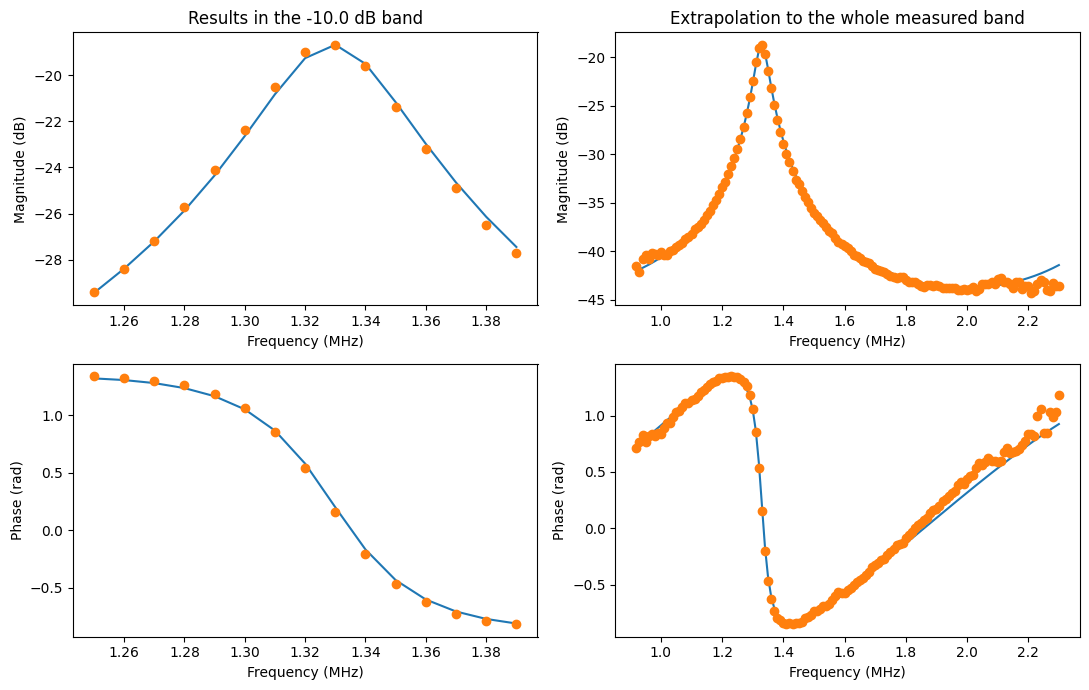

In [ ]:
cT_band = cT_layer(caso1, lfinEFA, cttest1.ResWindow(LIMITE).freq())

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0,0].set_title("Results in the -" + str(LIMITE) + " dB band")
ax[0,0].set_xlabel("Frequency (MHz)"); ax[0,0].set_ylabel("Magnitude (dB)")
ax[0,0].plot(cT_band.freq()/1e6, cT_band.mag(),
             cttest1.ResWindow(LIMITE).freq()/1e6, cttest1.ResWindow(LIMITE).mag(), "o")
ax[1,0].set_xlabel("Frequency (MHz)"); ax[1,0].set_ylabel("Phase (rad)")
ax[1,0].plot(cT_band.freq()/1e6, cT_band.phase(),
             cttest1.ResWindow(LIMITE).freq()/1e6, cttest1.ResWindow(LIMITE).phase(), "o")
ax[0,1].set_title("Extrapolation to the whole measured band")
ax[0,1].set_xlabel("Frequency (MHz)"); ax[0,1].set_ylabel("Magnitude (dB)")
ax[0,1].plot(cT_fin.freq()/1e6, cT_fin.mag(), test1[:,0]/1e6, test1[:,1], "o")
ax[1,1].set_xlabel("Frequency (MHz)"); ax[1,1].set_ylabel("Phase (rad)")
ax[1,1].plot(cT_fin.freq()/1e6, cT_fin.phase(), test1[:,0]/1e6, test1[:,2], "o")
plt.tight_layout(); plt.savefig("/content/ct14_fit.png", dpi=120); plt.show()

## 7. Interpretation, scope, and limitations / 解釈・範囲・限界

**Interpretation.** The gradient-descent fit converges on the authors' sample spectrum and recovers thickness and density close to the independent mechanical measurements (~140 µm, ~340 kg/m³) and close to the authors' own published notebook output for this file. This exercises exactly the data-processing step the paper describes in Section 3.5 (inverse problem from the first thickness resonance) and illustrates the leaf-parameter extraction workflow of Sections 5.1.1/5.2.1 (paper Table 3), which uses the same code on leaf spectra.

**Scope / limitations.**
- One membrane example — **not** a reproduction of the paper's Vitis vinifera / Coffea arabica leaf results; the leaf spectra and fitted leaf parameters (beyond Table 3 values in the text) are not publicly archived.
- The transducer hardware, calibration and GUI workflow (MATLAB/Labview) of Sections 3–4 are out of scope; only the Python data processing exists publicly.
- Python 2.7 → 3 translation by AI assistance, numerics unchanged; license status of the repository: no license file present — verify with the author before reuse.

**解釈。** 勾配降下法は著者のサンプルスペクトルで収束し、独立測定値（約 140 µm、約 340 kg/m³）および著者ノートブック出力に近い厚み・密度を復元します。これは論文 §3.5 の逆問題処理、および同じコードを葉スペクトルに適用する §5.1.1/§5.2.1（Table 3）のワークフローを実演するものです。

**範囲・限界。** 単一の膜試料の例であり、論文の Vitis vinifera / Coffea arabica の葉の結果の再現ではありません。葉スペクトルは公開アーカイブがなく、送受信器ハードウェア・校正・GUI（MATLAB/Labview）は範囲外です。リポジトリにライセンスファイルはないため、再利用前に著者へ確認してください。

**References.**
1. Gómez Álvarez-Arenas, T. et al. Ultrasonic Sensing of Plant Water Needs for Agriculture. *Sensors* 2016, 16(7), 1089. https://doi.org/10.3390/s16071089
2. Author code: https://github.com/usbiomat/ultrasonic-thickness-resonance (commit `09f11ea846ec84d575177dbce773388a4b590f3f`), including `Thickness_resonance_CT14_GD.ipynb` and `data.dat`.
3. Method background: Gómez Álvarez-Arenas, T. *Ultrasonics* 50(2):104–109 (2010), DOI 10.1016/j.ultras.2009.09.009 (cited in the author notebook).

Execution status: validated end-to-end in a fresh Google Colab CPU runtime (see notebook outputs). 実行状態：新規 Colab CPU ランタイムで全体を実行し検証済み。